In [19]:
# Cell 1: Imports & Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              classification_report, confusion_matrix, accuracy_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Create output folders (relative to project root, one level up from notebooks/)
os.makedirs("../outputs", exist_ok=True)
os.makedirs("../models", exist_ok=True)

print("Working directory:", os.getcwd())
print("Libraries loaded successfully.")

Working directory: C:\Users\dell\Desktop\Smart_Inventory_Intelligence\notebooks
Libraries loaded successfully.


In [20]:
# Cell 2: Load Datasets
demand = pd.read_csv("../data/demand_forecasting.csv")
inventory = pd.read_csv("../data/inventory_monitoring.csv")
pricing = pd.read_csv("../data/pricing_optimization.csv")

for name, d in [("Demand", demand), ("Inventory", inventory), ("Pricing", pricing)]:
    print(f"{name}: {d.shape[0]} rows, {d.shape[1]} cols")

demand.head()

Demand: 10000 rows, 10 cols
Inventory: 10000 rows, 9 cols
Pricing: 10000 rows, 10 cols


,Product ID,Date,Store ID,Sales Quantity,Price,Promotions,Seasonality Factors,External Factors,Demand Trend,Customer Segments
0,4277,2024-01-03,48,330,24.38,No,Festival,Competitor Pricing,Increasing,Regular
1,5540,2024-04-29,10,334,74.98,Yes,Holiday,Weather,Stable,Premium
2,5406,2024-01-11,67,429,24.83,Yes,Holiday,Economic Indicator,Decreasing,Premium
3,5617,2024-04-04,17,298,13.41,No,NaN,Economic Indicator,Stable,Regular
4,3480,2024-12-14,33,344,94.96,Yes,Festival,Weather,Increasing,Regular


In [21]:
# Cell 3: Data Quality Check
def data_report(df, name):
    print(f"\n--- {name} ---")
    missing = df.isnull().sum()
    print("Missing values:\n", missing[missing > 0] if missing.sum() > 0 else "None")
    print("Duplicates:", df.duplicated().sum())

for name, d in [("Demand", demand), ("Inventory", inventory), ("Pricing", pricing)]:
    data_report(d, name)


--- Demand ---
Missing values:
 Seasonality Factors    3315
External Factors       2426
dtype: int64
Duplicates: 0

--- Inventory ---
Missing values:
 None
Duplicates: 0

--- Pricing ---
Missing values:
 None
Duplicates: 0


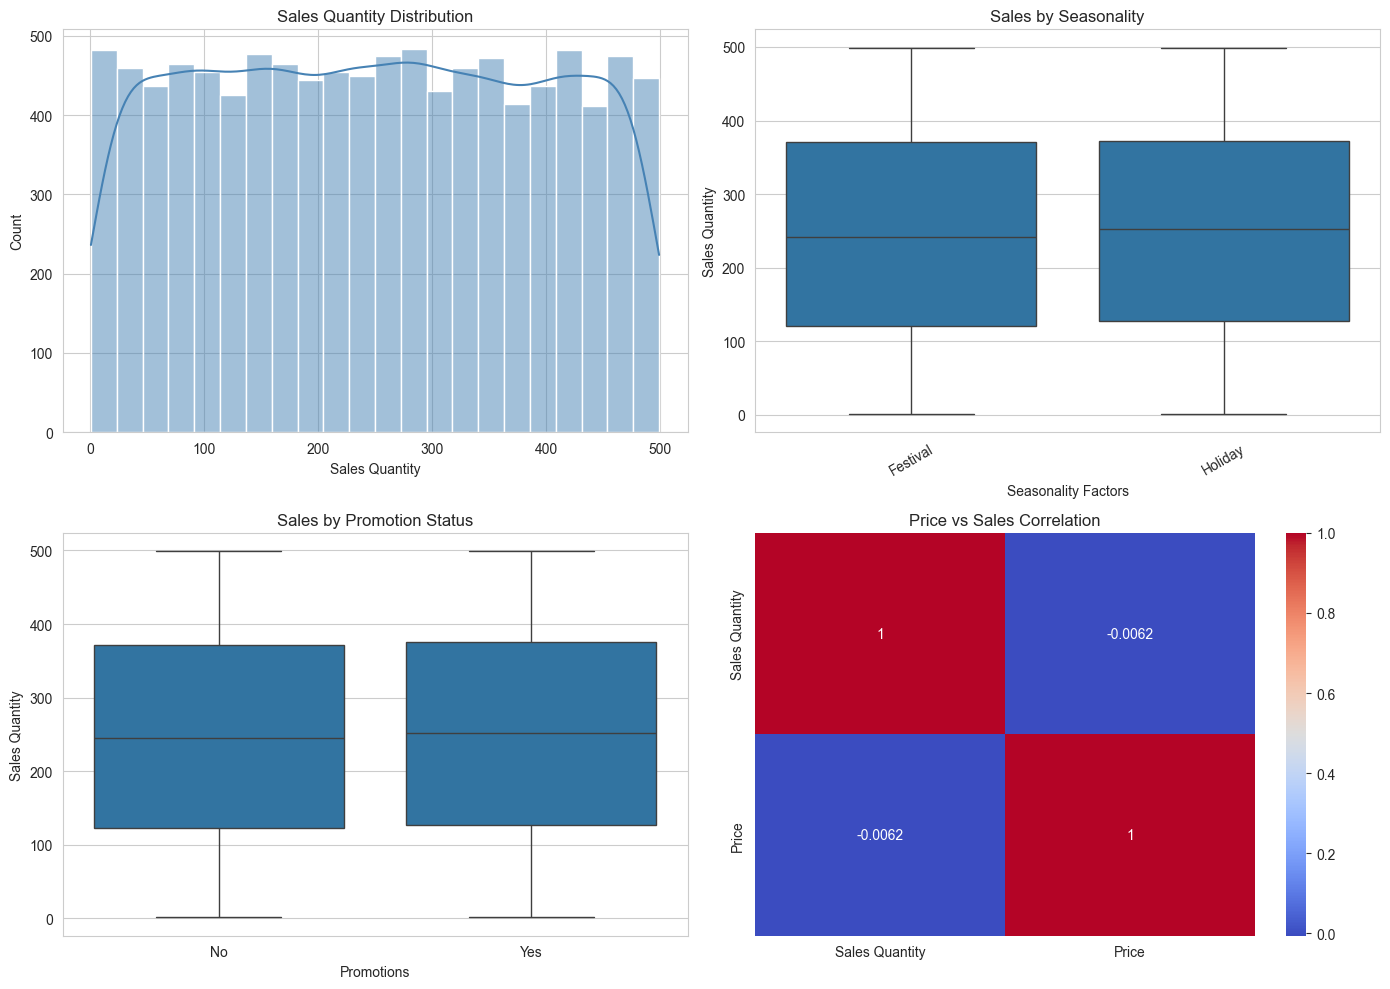

In [22]:
# Cell 4: Exploratory Data Analysis - Demand Patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(demand["Sales Quantity"], kde=True, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Sales Quantity Distribution")

sns.boxplot(x="Seasonality Factors", y="Sales Quantity", data=demand, ax=axes[0,1])
axes[0,1].set_title("Sales by Seasonality")
axes[0,1].tick_params(axis='x', rotation=30)

sns.boxplot(x="Promotions", y="Sales Quantity", data=demand, ax=axes[1,0])
axes[1,0].set_title("Sales by Promotion Status")

corr = demand[["Sales Quantity", "Price"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Price vs Sales Correlation")

plt.tight_layout()
plt.savefig("../outputs/eda_demand.png", dpi=150)
plt.show()

In [23]:
# Cell 5: Merge All Datasets
df = demand.merge(inventory, on=["Product ID", "Store ID"], how="left")
df = df.merge(pricing, on=["Product ID", "Store ID"], how="left", suffixes=("", "_pr"))
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["DayOfWeek"] = df["Date"].dt.dayofweek

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (10000, 28)


,Product ID,Date,Store ID,Sales Quantity,Price,Promotions,Seasonality Factors,External Factors,Demand Trend,Customer Segments,...,Competitor Prices,Discounts,Sales Volume,Customer Reviews,Return Rate (%),Storage Cost,Elasticity Index,Month,Quarter,DayOfWeek
0,4277,2024-01-03,48,330,24.38,No,Festival,Competitor Pricing,Increasing,Regular,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2
1,5540,2024-04-29,10,334,74.98,Yes,Holiday,Weather,Stable,Premium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,0
2,5406,2024-01-11,67,429,24.83,Yes,Holiday,Economic Indicator,Decreasing,Premium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,3
3,5617,2024-04-04,17,298,13.41,No,NaN,Economic Indicator,Stable,Regular,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,3
4,3480,2024-12-14,33,344,94.96,Yes,Festival,Weather,Increasing,Regular,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,4,5


In [24]:
# Cell 6: Encode Categorical Features
cat_cols = ["Promotions", "Seasonality Factors", "External Factors",
            "Demand Trend", "Customer Segments"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

df.fillna(df.median(numeric_only=True), inplace=True)
print("Encoding complete. Remaining missing values:", df.isnull().sum().sum())

Encoding complete. Remaining missing values: 9878


In [25]:
# Cell 7: Demand Forecasting - Model Comparison
features = ["Price", "Promotions", "Seasonality Factors", "External Factors",
            "Customer Segments", "Month", "Quarter", "DayOfWeek"]
X = df[features]
y = df["Sales Quantity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=42)
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    cv_score = cross_val_score(m, X, y, cv=5, scoring="r2").mean()
    results.append([name, mae, rmse, r2, cv_score])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2", "CV_R2"])
results_df.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2,CV_R2
0,Linear Regression,125.630509,145.206606,-0.001711,-0.000688
2,Gradient Boosting,126.348924,146.312653,-0.017029,-0.013813
1,Random Forest,126.645469,146.809383,-0.023947,-0.021304


In [26]:
# Cell 8: Hyperparameter Tuning - Best Model (Random Forest)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                            cv=3, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best Params:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

final_pred = best_model.predict(X_test)
print("Test R2:", r2_score(y_test, final_pred))
print("Test MAE:", mean_absolute_error(y_test, final_pred))

Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R2: -0.01681587146096386
Test R2: -0.015760851204220883
Test MAE: 126.26105514794828


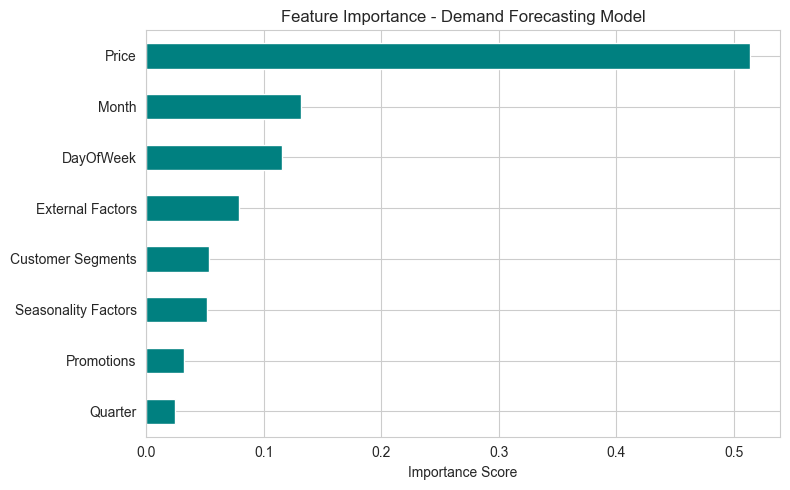

In [27]:
# Cell 9: Feature Importance
importances = pd.Series(best_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="teal")
plt.title("Feature Importance - Demand Forecasting Model")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150)
plt.show()

Accuracy: 0.997

               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1788
           1       1.00      0.97      0.99       212

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



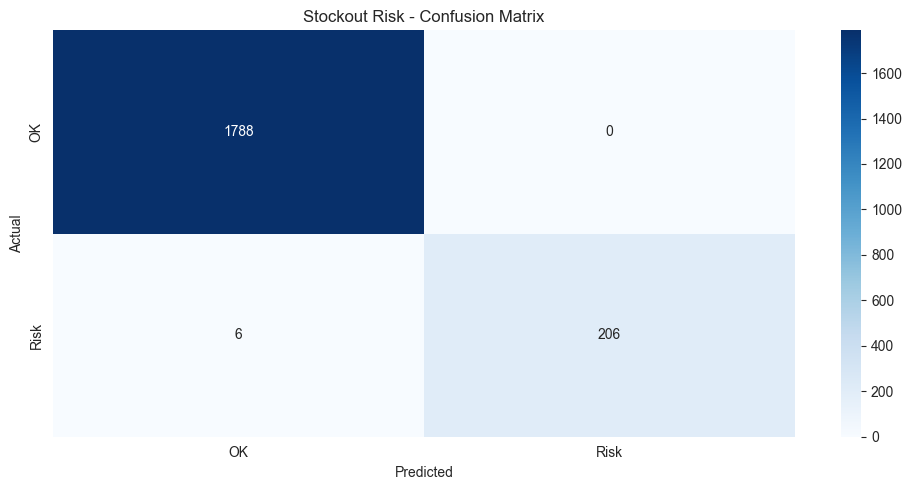

In [28]:
# Cell 10: Inventory Monitoring - Stockout Risk Classification
inventory["Stockout_Risk"] = np.where(
    inventory["Stock Levels"] <= inventory["Reorder Point"], 1, 0
)

inv_features = ["Stock Levels", "Supplier Lead Time (days)", "Stockout Frequency",
                 "Reorder Point", "Warehouse Capacity", "Order Fulfillment Time (days)"]
Xi = inventory[inv_features]
yi = inventory["Stockout_Risk"]

Xi_train, Xi_test, yi_train, yi_test = train_test_split(Xi, yi, test_size=0.2,
                                                           random_state=42, stratify=yi)

clf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
clf.fit(Xi_train, yi_train)
yi_pred = clf.predict(Xi_test)

print("Accuracy:", accuracy_score(yi_test, yi_pred))
print("\n", classification_report(yi_test, yi_pred))

cm = confusion_matrix(yi_test, yi_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["OK","Risk"], yticklabels=["OK","Risk"])
plt.title("Stockout Risk - Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../outputs/stockout_confusion_matrix.png", dpi=150)
plt.show()

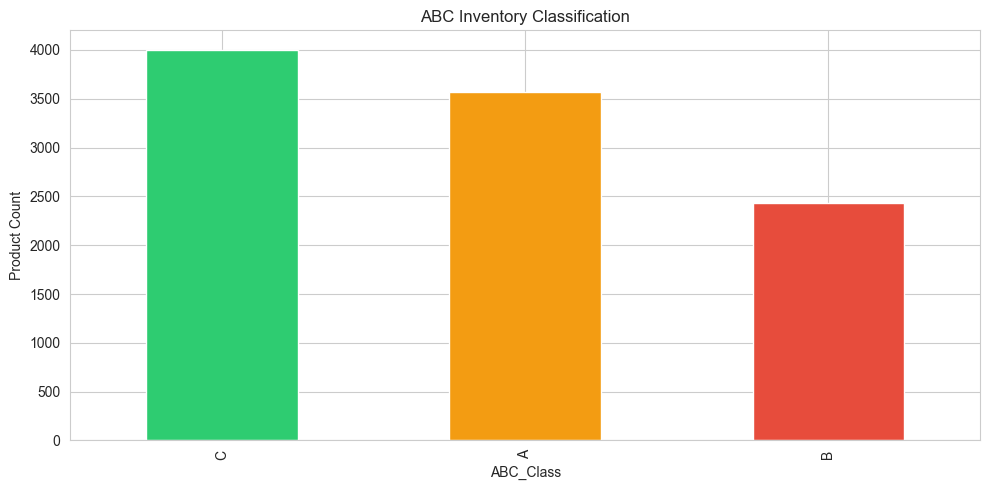

In [29]:
# Cell 11: Inventory - ABC Segmentation by Stock Value Proxy
inventory["Value_Score"] = inventory["Stock Levels"] * inventory["Order Fulfillment Time (days)"]
inventory = inventory.sort_values("Value_Score", ascending=False).reset_index(drop=True)
inventory["Cumulative_Pct"] = inventory["Value_Score"].cumsum() / inventory["Value_Score"].sum() * 100

def abc_class(pct):
    if pct <= 70:
        return "A"
    elif pct <= 90:
        return "B"
    else:
        return "C"

inventory["ABC_Class"] = inventory["Cumulative_Pct"].apply(abc_class)

inventory["ABC_Class"].value_counts().plot(kind="bar", color=["#2ecc71","#f39c12","#e74c3c"])
plt.title("ABC Inventory Classification")
plt.ylabel("Product Count")
plt.tight_layout()
plt.savefig("../outputs/abc_classification.png", dpi=150)
plt.show()

In [30]:
# Cell 12: Pricing Optimization - Elasticity Modeling
pricing["Price_Gap"] = pricing["Price"] - pricing["Competitor Prices"]
pricing["Price_Gap_Pct"] = (pricing["Price_Gap"] / pricing["Competitor Prices"]) * 100

price_features = ["Price", "Competitor Prices", "Discounts", "Customer Reviews",
                   "Return Rate (%)", "Storage Cost"]
Xp = pricing[price_features]
yp = pricing["Sales Volume"]

Xp_train, Xp_test, yp_train, yp_test = train_test_split(Xp, yp, test_size=0.2, random_state=42)

price_model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=42)
price_model.fit(Xp_train, yp_train)
yp_pred = price_model.predict(Xp_test)

print("Pricing Model R2:", r2_score(yp_test, yp_pred))
print("Pricing Model MAE:", mean_absolute_error(yp_test, yp_pred))

pricing["Suggested_Action"] = np.where(
    pricing["Elasticity Index"] > 1.5,
    np.where(pricing["Price_Gap"] > 0, "Lower Price", "Maintain"),
    "Raise Price"
)
pricing[["Product ID", "Price", "Competitor Prices", "Elasticity Index", "Suggested_Action"]].head(10)

Pricing Model R2: -0.02353397870272267
Pricing Model MAE: 127.36948992021154


,Product ID,Price,Competitor Prices,Elasticity Index,Suggested_Action
0,9502,31.61,56.14,1.78,Maintain
1,2068,35.51,63.04,1.67,Maintain
2,7103,6.54,30.61,2.46,Maintain
3,5288,13.61,15.94,0.88,Raise Price
4,7212,62.68,30.64,1.00,Raise Price
5,4809,44.87,68.31,1.48,Raise Price
6,2127,34.99,88.04,2.45,Maintain
7,2914,27.91,59.28,1.70,Maintain
8,7111,57.49,8.87,1.99,Lower Price
9,3500,62.71,75.97,2.00,Maintain


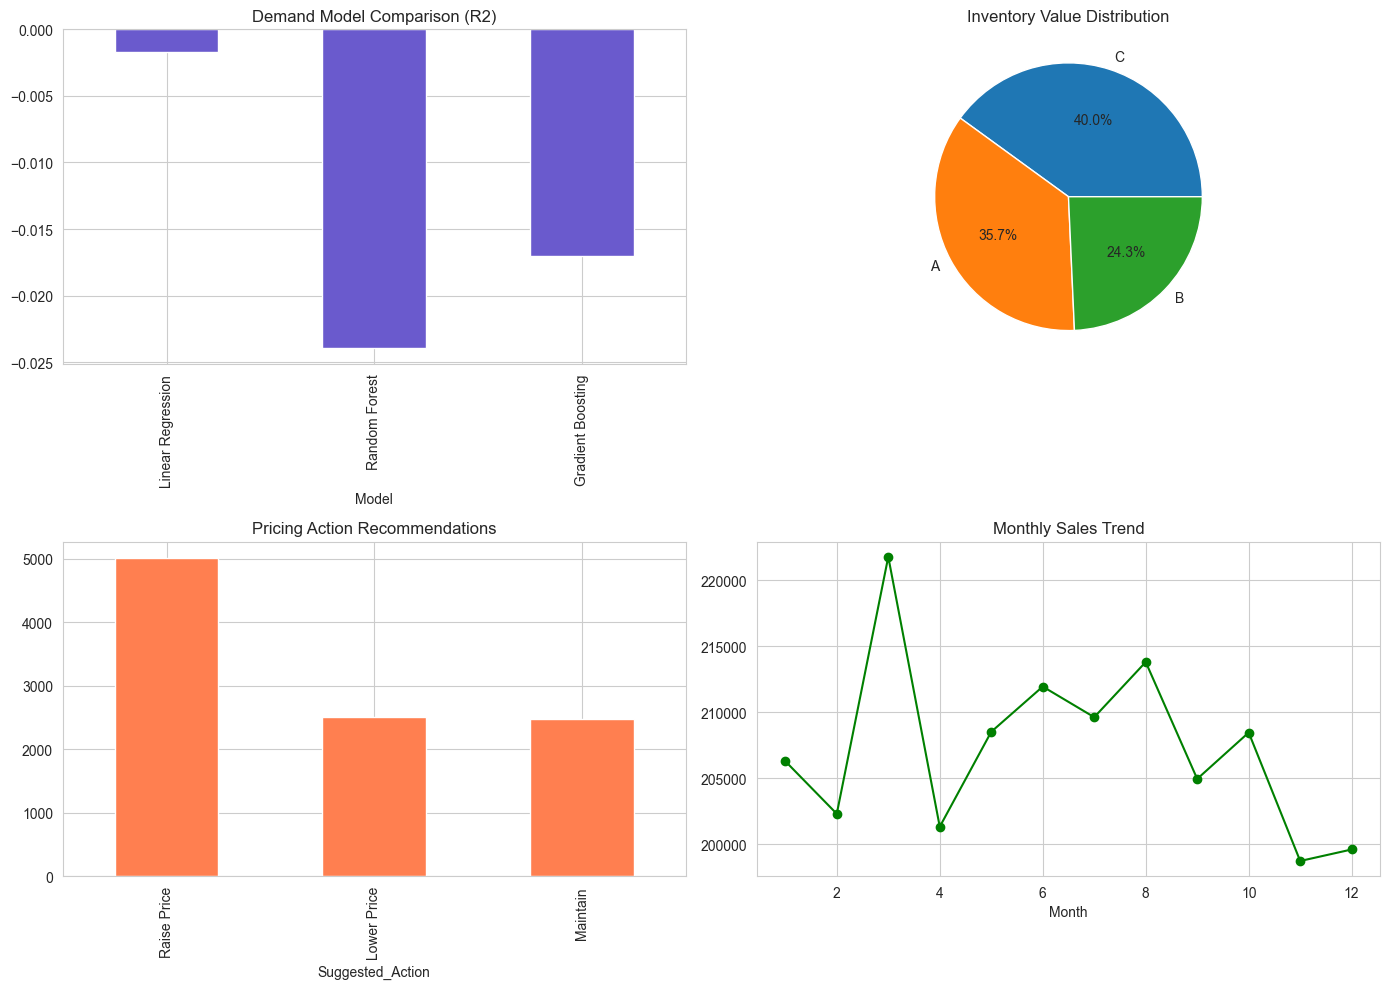

In [31]:
# Cell 13: Business Insights Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

results_df.plot(x="Model", y="R2", kind="bar", ax=axes[0,0], legend=False, color="slateblue")
axes[0,0].set_title("Demand Model Comparison (R2)")

inventory["ABC_Class"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[0,1])
axes[0,1].set_title("Inventory Value Distribution")
axes[0,1].set_ylabel("")

pricing["Suggested_Action"].value_counts().plot(kind="bar", ax=axes[1,0], color="coral")
axes[1,0].set_title("Pricing Action Recommendations")

df.groupby("Month")["Sales Quantity"].sum().plot(marker="o", ax=axes[1,1], color="green")
axes[1,1].set_title("Monthly Sales Trend")

plt.tight_layout()
plt.savefig("../outputs/dashboard_summary.png", dpi=150)
plt.show()

In [32]:
# Cell 14: Save Models & Final Outputs
joblib.dump(best_model, "../models/demand_forecast_model.pkl")
joblib.dump(clf, "../models/stockout_risk_model.pkl")
joblib.dump(price_model, "../models/pricing_model.pkl")

inventory.to_csv("../outputs/inventory_with_abc.csv", index=False)
pricing.to_csv("../outputs/pricing_recommendations.csv", index=False)
results_df.to_csv("../outputs/model_comparison.csv", index=False)

print("All models and outputs saved successfully.")
print("\nProject Summary:")
print(f"- Demand Forecast R2: {r2_score(y_test, final_pred):.3f}")
print(f"- Stockout Risk Accuracy: {accuracy_score(yi_test, yi_pred):.3f}")
print(f"- Pricing Model R2: {r2_score(yp_test, yp_pred):.3f}")

All models and outputs saved successfully.

Project Summary:
- Demand Forecast R2: -0.016
- Stockout Risk Accuracy: 0.997
- Pricing Model R2: -0.024
